<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Cosmos003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize


In [ ]:
t0 = 4.35e17  # seconds

def t_of_z(z, alpha):
    return t0 * (1 + z)**(-1 / alpha)

def H_HES(z, alpha):
    return alpha / t_of_z(z, alpha)

def d_L_HES(z, alpha):
    integrand = lambda z_prime: 1 / H_HES(z_prime, alpha)
    integral, _ = quad(integrand, 0, z)
    return (1 + z) * integral

def mu_HES(z, alpha):
    d_L = d_L_HES(z, alpha)
    return 5 * np.log10(d_L * 3.086e22) - 5  # Convert to parsecs


In [ ]:
import pandas as pd

# Load the standardized Pantheon+ dataset
df = pd.read_csv('/content/Pantheon_SH0ES.dat', sep=r'\s+', comment='#')

# Print column names to confirm structure
print("Available columns:", df.columns)

# Extract redshift, distance modulus, and uncertainty
z_data = df['zCMB'].values
mu_data = df['MU_SH0ES'].values
sigma_mu = df['MU_SH0ES_ERR_DIAG'].values

print(f"Loaded {len(z_data)} supernovae")


Available columns: Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')
Loaded 1701 supernovae


In [ ]:
def chi_squared(alpha):
    mu_model = np.array([mu_HES(z, alpha[0]) for z in z_data])
    return np.sum(((mu_data - mu_model) / sigma_mu)**2)

result = minimize(chi_squared, x0=[0.72])
alpha_best = result.x[0]
chi2 = result.fun
dof = len(z_data) - 1


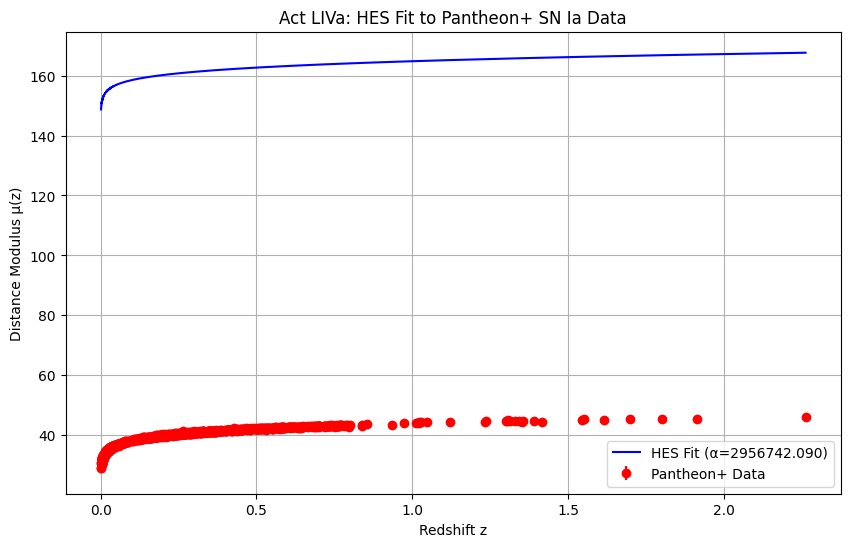

In [ ]:
mu_fit = np.array([mu_HES(z, alpha_best) for z in z_data])
residuals = mu_data - mu_fit

plt.figure(figsize=(10, 6))
plt.errorbar(z_data, mu_data, yerr=sigma_mu, fmt='o', label='Pantheon+ Data', color='red')
plt.plot(z_data, mu_fit, label=f'HES Fit (α={alpha_best:.3f})', color='blue')
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ(z)')
plt.title('Act LIVa: HES Fit to Pantheon+ SN Ia Data')
plt.legend()
plt.grid(True)
plt.show()
